# Image Captioning: Baseline vs Attention Comparison

This notebook implements and compares two models:
1. **Baseline**: CNN-LSTM without attention mechanism
2. **With Attention**: CNN-LSTM with Bahdanau attention

**Goal**: Demonstrate the improvement that attention brings to image captioning



## 1. GPU Setup and Verification

In [48]:
import torch
import sys

print("="*60)
print("GPU VERIFICATION")
print("="*60)
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"✓ GPU Detected: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("⚠️ No GPU detected - training will be slow!")
print("="*60)

GPU VERIFICATION
Python: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
PyTorch: 2.7.1+cu118
CUDA Available: True
✓ GPU Detected: NVIDIA GeForce RTX 4080 Laptop GPU
  CUDA Version: 11.8
  GPU Memory: 11.99 GB


## 2. Import Libraries

In [49]:
import os
import re
import random
import urllib.request
import zipfile
from collections import Counter

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm import tqdm

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 3. Configuration (Simba)

In [87]:
class Config:
    """Hyperparameters and paths"""
    # Data paths
    data_dir = "data/Flickr8k"
    images_dir = os.path.join(data_dir, "Images")
    captions_file = os.path.join(data_dir, "captions.txt")

    # Training split ratios
    train_ratio = 0.8
    val_ratio = 0.1

    # Vocabulary settings
    min_freq = 5
    max_caption_len = 40

    # Model architecture
    embed_dim = 256
    encoder_dim = 512
    decoder_dim = 512
    attention_dim = 256

    # Training hyperparameters
    batch_size = 64
    num_workers = 0
    lr = 1e-4
    num_epochs = 10
    grad_clip = 5.0
    
    # Device
    device = (
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )

    # Special tokens
    pad_token = "<pad>"
    start_token = "<start>"
    end_token = "<end>"
    unk_token = "<unk>"

cfg = Config()
print(f"Using device: {cfg.device}")

Using device: cuda


## 4. Utility Functions

In [51]:
def clean_caption(caption: str) -> str:
    """Clean and normalize caption text"""
    caption = caption.lower().strip()
    caption = re.sub(r"[^a-z0-9,.!?']", " ", caption)
    caption = re.sub(r"\s+", " ", caption).strip()
    return caption

def tokenize(caption: str):
    """Simple whitespace tokenization"""
    return caption.split()

## 5. Vocabulary Class (Ian)

In [52]:
class Vocabulary:
    """Build and manage vocabulary"""
    def __init__(self, min_freq=5):
        self.min_freq = min_freq
        self.freqs = Counter()
        self.stoi = {}
        self.itos = []

        self.pad_token = cfg.pad_token
        self.start_token = cfg.start_token
        self.end_token = cfg.end_token
        self.unk_token = cfg.unk_token

    def build(self, all_captions):
        """Build vocabulary from captions"""
        for cap in all_captions:
            tokens = tokenize(clean_caption(cap))
            self.freqs.update(tokens)

        self.itos = [
            self.pad_token,
            self.start_token,
            self.end_token,
            self.unk_token,
        ]
        self.stoi = {tok: idx for idx, tok in enumerate(self.itos)}

        for word, freq in self.freqs.items():
            if freq >= self.min_freq and word not in self.stoi:
                self.stoi[word] = len(self.itos)
                self.itos.append(word)

    def numericalize(self, caption: str):
        """Convert caption to token IDs"""
        tokens = tokenize(clean_caption(caption))
        return [self.stoi.get(tok, self.stoi[self.unk_token]) for tok in tokens]

    def __len__(self):
        return len(self.itos)

## 6. Data Loading Functions (Tinashe)

In [53]:
def load_captions(captions_file):
    """Load captions from file"""
    image2caps = {}
    all_pairs = []

    with open(captions_file, "r") as f:
        for line in f:
            if not line.strip():
                continue

            parts = line.strip().split(",", 1)
            if len(parts) != 2:
                continue
                
            img_id, caption = parts
            img_name = img_id.strip()
            caption = caption.strip()

            if not img_name.lower().endswith(".jpg"):
                continue

            image2caps.setdefault(img_name, []).append(caption)
            all_pairs.append((img_name, caption))

    return image2caps, all_pairs

def train_val_test_split(all_pairs, train_ratio=0.8, val_ratio=0.1, seed=42):
    """Split data into train/val/test sets"""
    random.seed(seed)
    random.shuffle(all_pairs)
    
    n = len(all_pairs)
    n_train = int(train_ratio * n)
    n_val = int(val_ratio * n)
    
    train_data = all_pairs[:n_train]
    val_data = all_pairs[n_train:n_train + n_val]
    test_data = all_pairs[n_train + n_val:]
    
    return train_data, val_data, test_data

## 7. Dataset and DataLoader (Tinashe)

In [54]:
class FlickrCaptionDataset(Dataset):
    """Flickr8k dataset loader"""
    def __init__(self, image_caption_pairs, images_dir, vocab: Vocabulary,
                 transform=None, max_len=40):
        self.data = image_caption_pairs
        self.images_dir = images_dir
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len

        self.start_idx = vocab.stoi[cfg.start_token]
        self.end_idx = vocab.stoi[cfg.end_token]
        self.pad_idx = vocab.stoi[cfg.pad_token]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name, caption = self.data[idx]
        img_path = os.path.join(self.images_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        token_ids = self.vocab.numericalize(caption)
        token_ids = token_ids[: self.max_len - 2]
        caption_ids = [self.start_idx] + token_ids + [self.end_idx]
        length = len(caption_ids)

        return image, torch.tensor(caption_ids, dtype=torch.long), length

class CaptionCollate:
    """Custom collate function for variable-length captions"""
    def __init__(self, pad_idx: int):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        images, captions, lengths = zip(*batch)
        images = torch.stack(images, dim=0)

        max_len = max(lengths)
        padded_captions = torch.full(
            (len(captions), max_len),
            fill_value=self.pad_idx,
            dtype=torch.long,
        )

        for i, cap in enumerate(captions):
            end = cap.shape[0]
            padded_captions[i, :end] = cap

        lengths = torch.tensor(lengths, dtype=torch.long)

        return images, padded_captions, lengths

## 8. Download Dataset (Tinashe)

In [55]:
def download_flickr8k():
    """Download and extract Flickr8k dataset"""
    print("Downloading Flickr8k dataset...")
    
    os.makedirs('data/Flickr8k', exist_ok=True)
    
    dataset_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
    captions_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"
    
    print("Downloading images...")
    urllib.request.urlretrieve(dataset_url, "Flickr8k_Dataset.zip")
    
    print("Downloading captions...")
    urllib.request.urlretrieve(captions_url, "Flickr8k_text.zip")
    
    print("Extracting...")
    with zipfile.ZipFile("Flickr8k_Dataset.zip", 'r') as zip_ref:
        zip_ref.extractall("data/Flickr8k")
    
    with zipfile.ZipFile("Flickr8k_text.zip", 'r') as zip_ref:
        zip_ref.extractall("data/Flickr8k")
    
    if os.path.exists("data/Flickr8k/Flickr8k.token.txt"):
        os.rename("data/Flickr8k/Flickr8k.token.txt", "data/Flickr8k/captions.txt")
    
    os.remove("Flickr8k_Dataset.zip")
    os.remove("Flickr8k_text.zip")
    
    print("✓ Dataset ready!")

if not os.path.exists(cfg.captions_file):
    download_flickr8k()
else:
    print("✓ Dataset already exists!")

✓ Dataset already exists!


## 9. Prepare Data (Ian)

In [56]:
# Load captions
image2caps, all_pairs = load_captions(cfg.captions_file)
train_pairs, val_pairs, test_pairs = train_val_test_split(
    all_pairs, cfg.train_ratio, cfg.val_ratio
)

# Build vocabulary
vocab = Vocabulary(min_freq=cfg.min_freq)
vocab.build([cap for _, cap in train_pairs])
cfg.pad_token_id = vocab.stoi[cfg.pad_token]

print(f"Vocabulary size: {len(vocab)}")
print(f"Training samples: {len(train_pairs)}")
print(f"Validation samples: {len(val_pairs)}")
print(f"Test samples: {len(test_pairs)}")

Vocabulary size: 2662
Training samples: 32364
Validation samples: 4045
Test samples: 4046


## 10. Create DataLoaders (Simba)

In [57]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Datasets
train_dataset = FlickrCaptionDataset(
    train_pairs, cfg.images_dir, vocab,
    transform=train_transform, max_len=cfg.max_caption_len
)
val_dataset = FlickrCaptionDataset(
    val_pairs, cfg.images_dir, vocab,
    transform=val_transform, max_len=cfg.max_caption_len
)
test_dataset = FlickrCaptionDataset(
    test_pairs, cfg.images_dir, vocab,
    transform=val_transform, max_len=cfg.max_caption_len
)

collate = CaptionCollate(pad_idx=cfg.pad_token_id)

# DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=cfg.batch_size, shuffle=True,
    num_workers=cfg.num_workers, collate_fn=collate, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, collate_fn=collate, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, collate_fn=collate, pin_memory=True
)

print("✓ DataLoaders created")

✓ DataLoaders created


## 11. CNN Encoder (Shared by Both Models)  (Tinashe)

In [58]:
class EncoderCNN(nn.Module):
    """ResNet-50 based encoder"""
    def __init__(self, encoded_image_size=14, encoder_dim=512):
        super().__init__()
        self.enc_image_size = encoded_image_size

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        modules = list(resnet.children())[:-2]
        self.cnn = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.conv_project = nn.Conv2d(2048, encoder_dim, kernel_size=1, stride=1)
        self.fine_tune(False)

    def forward(self, images):
        features = self.cnn(images)
        features = self.adaptive_pool(features)
        features = self.conv_project(features)
        B, D, H, W = features.size()
        features = features.permute(0, 2, 3, 1).view(B, -1, D)
        return features

    def fine_tune(self, fine_tune=True):
        for p in self.cnn.parameters():
            p.requires_grad = False
        for c in list(self.cnn.children())[-2:]:
            for p in c.parameters():
                p.requires_grad = fine_tune

## 12. BASELINE MODEL - CNN-LSTM WITHOUT Attention (Tinashe and Ian)

In [59]:
class BaselineDecoderLSTM(nn.Module):
    """LSTM decoder WITHOUT attention (Baseline Model)"""
    def __init__(self, vocab_size, embed_dim, encoder_dim, decoder_dim, pad_idx):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.embed_dim = embed_dim
        self.decoder_dim = decoder_dim
        self.vocab_size = vocab_size
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        
        # Initialize hidden state from global image features
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        
        # LSTM takes word embeddings only (no attention context)
        self.lstm_cell = nn.LSTMCell(embed_dim, decoder_dim)
        
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def init_hidden_state(self, encoder_out):
        """Initialize LSTM from mean-pooled encoder features"""
        mean_encoder = encoder_out.mean(dim=1)  # (B, encoder_dim)
        h = self.init_h(mean_encoder)
        c = self.init_c(mean_encoder)
        return h, c

    def forward(self, encoder_out, captions, lengths):
        batch_size = encoder_out.size(0)

        # Sort by length
        lengths_sorted, sort_idx = lengths.sort(dim=0, descending=True)
        encoder_out = encoder_out[sort_idx]
        captions = captions[sort_idx]

        # Embed captions
        embeddings = self.embedding(captions)

        # Initialize LSTM
        h, c = self.init_hidden_state(encoder_out)

        decode_lengths = (lengths_sorted - 1).tolist()
        max_decode_len = max(decode_lengths)

        predictions = torch.zeros(batch_size, max_decode_len, self.vocab_size).to(encoder_out.device)

        # Decode WITHOUT attention
        for t in range(max_decode_len):
            batch_t = sum([l > t for l in decode_lengths])
            
            # Only word embedding as input (NO context vector)
            lstm_input = embeddings[:batch_t, t, :]
            h_new, c_new = self.lstm_cell(lstm_input, (h[:batch_t], c[:batch_t]))

            h = torch.cat([h_new, h[batch_t:]], dim=0)
            c = torch.cat([c_new, c[batch_t:]], dim=0)

            preds = self.fc(self.dropout(h_new))
            predictions[:batch_t, t, :] = preds

        return predictions, captions, decode_lengths, sort_idx

## 13. ATTENTION MODEL - CNN-LSTM WITH Attention (Simba)

In [60]:
class BahdanauAttention(nn.Module):
    """Additive attention mechanism"""
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)
        att = self.full_att(self.relu(att1 + att2)).squeeze(2)
        alpha = self.softmax(att)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

class AttentionDecoderLSTM(nn.Module):
    """LSTM decoder WITH attention (Improved Model)"""
    def __init__(self, vocab_size, embed_dim, encoder_dim, decoder_dim, attention_dim, pad_idx):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.embed_dim = embed_dim
        self.decoder_dim = decoder_dim
        self.vocab_size = vocab_size
        self.pad_idx = pad_idx

        self.attention = BahdanauAttention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        
        # LSTM takes word embedding + context vector
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def init_hidden_state(self, encoder_out):
        mean_encoder = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder)
        c = self.init_c(mean_encoder)
        return h, c

    def forward(self, encoder_out, captions, lengths):
        batch_size = encoder_out.size(0)
        L = encoder_out.size(1)

        lengths_sorted, sort_idx = lengths.sort(dim=0, descending=True)
        encoder_out = encoder_out[sort_idx]
        captions = captions[sort_idx]

        embeddings = self.embedding(captions)
        h, c = self.init_hidden_state(encoder_out)

        decode_lengths = (lengths_sorted - 1).tolist()
        max_decode_len = max(decode_lengths)

        predictions = torch.zeros(batch_size, max_decode_len, self.vocab_size).to(encoder_out.device)
        alphas = torch.zeros(batch_size, max_decode_len, L).to(encoder_out.device)

        # Decode WITH attention
        for t in range(max_decode_len):
            batch_t = sum([l > t for l in decode_lengths])
            
            # Compute attention
            context, alpha = self.attention(encoder_out[:batch_t], h[:batch_t])
            gate = self.sigmoid(self.f_beta(h[:batch_t]))
            context = gate * context

            # Concatenate word embedding + context
            lstm_input = torch.cat([embeddings[:batch_t, t, :], context], dim=1)
            h_new, c_new = self.lstm_cell(lstm_input, (h[:batch_t], c[:batch_t]))

            h = torch.cat([h_new, h[batch_t:]], dim=0)
            c = torch.cat([c_new, c[batch_t:]], dim=0)

            preds = self.fc(self.dropout(h_new))
            predictions[:batch_t, t, :] = preds
            alphas[:batch_t, t, :] = alpha

        return predictions, captions, decode_lengths, alphas, sort_idx

## 14. Training Functions (Simba and Ian)

In [61]:
def train_baseline_one_epoch(encoder, decoder, criterion, optimizer, train_loader, epoch):
    """Train baseline model for one epoch"""
    encoder.train()
    decoder.train()
    total_loss = 0.0

    for images, captions, lengths in tqdm(train_loader, desc=f"[BASELINE] Epoch {epoch}"):
        images = images.to(cfg.device, non_blocking=True)
        captions = captions.to(cfg.device, non_blocking=True)
        lengths = lengths.to(cfg.device, non_blocking=True)

        optimizer.zero_grad()
        encoder_out = encoder(images)
        scores, caps_sorted, decode_lengths, sort_idx = decoder(encoder_out, captions, lengths)

        targets = caps_sorted[:, 1:]
        scores_packed = []
        targets_packed = []
        for i, l in enumerate(decode_lengths):
            scores_packed.append(scores[i, :l, :])
            targets_packed.append(targets[i, :l])

        scores_packed = torch.cat(scores_packed, dim=0)
        targets_packed = torch.cat(targets_packed, dim=0)
        loss = criterion(scores_packed, targets_packed)

        loss.backward()
        nn.utils.clip_grad_norm_(decoder.parameters(), cfg.grad_clip)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

def train_attention_one_epoch(encoder, decoder, criterion, optimizer, train_loader, epoch):
    """Train attention model for one epoch"""
    encoder.train()
    decoder.train()
    total_loss = 0.0

    for images, captions, lengths in tqdm(train_loader, desc=f"[ATTENTION] Epoch {epoch}"):
        images = images.to(cfg.device, non_blocking=True)
        captions = captions.to(cfg.device, non_blocking=True)
        lengths = lengths.to(cfg.device, non_blocking=True)

        optimizer.zero_grad()
        encoder_out = encoder(images)
        scores, caps_sorted, decode_lengths, alphas, sort_idx = decoder(
            encoder_out, captions, lengths
        )

        targets = caps_sorted[:, 1:]
        scores_packed = []
        targets_packed = []
        for i, l in enumerate(decode_lengths):
            scores_packed.append(scores[i, :l, :])
            targets_packed.append(targets[i, :l])

        scores_packed = torch.cat(scores_packed, dim=0)
        targets_packed = torch.cat(targets_packed, dim=0)
        loss = criterion(scores_packed, targets_packed)

        # Attention regularization
        alphas_reg = 1.0 * ((1.0 - alphas.sum(dim=1)) ** 2).mean()
        loss = loss + alphas_reg

        loss.backward()
        nn.utils.clip_grad_norm_(decoder.parameters(), cfg.grad_clip)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

@torch.no_grad()
def validate_baseline(encoder, decoder, criterion, val_loader, epoch):
    encoder.eval()
    decoder.eval()
    total_loss = 0.0

    for images, captions, lengths in tqdm(val_loader, desc=f"[BASELINE VAL] Epoch {epoch}"):
        images = images.to(cfg.device, non_blocking=True)
        captions = captions.to(cfg.device, non_blocking=True)
        lengths = lengths.to(cfg.device, non_blocking=True)

        encoder_out = encoder(images)
        scores, caps_sorted, decode_lengths, sort_idx = decoder(encoder_out, captions, lengths)

        targets = caps_sorted[:, 1:]
        scores_packed = []
        targets_packed = []
        for i, l in enumerate(decode_lengths):
            scores_packed.append(scores[i, :l, :])
            targets_packed.append(targets[i, :l])

        scores_packed = torch.cat(scores_packed, dim=0)
        targets_packed = torch.cat(targets_packed, dim=0)
        loss = criterion(scores_packed, targets_packed)
        total_loss += loss.item()

    return total_loss / len(val_loader)

@torch.no_grad()
def validate_attention(encoder, decoder, criterion, val_loader, epoch):
    encoder.eval()
    decoder.eval()
    total_loss = 0.0

    for images, captions, lengths in tqdm(val_loader, desc=f"[ATTENTION VAL] Epoch {epoch}"):
        images = images.to(cfg.device, non_blocking=True)
        captions = captions.to(cfg.device, non_blocking=True)
        lengths = lengths.to(cfg.device, non_blocking=True)

        encoder_out = encoder(images)
        scores, caps_sorted, decode_lengths, alphas, sort_idx = decoder(
            encoder_out, captions, lengths
        )

        targets = caps_sorted[:, 1:]
        scores_packed = []
        targets_packed = []
        for i, l in enumerate(decode_lengths):
            scores_packed.append(scores[i, :l, :])
            targets_packed.append(targets[i, :l])

        scores_packed = torch.cat(scores_packed, dim=0)
        targets_packed = torch.cat(targets_packed, dim=0)
        loss = criterion(scores_packed, targets_packed)
        alphas_reg = 1.0 * ((1.0 - alphas.sum(dim=1)) ** 2).mean()
        loss = loss + alphas_reg
        total_loss += loss.item()

    return total_loss / len(val_loader)

## 15. Caption Generation Functions (Ian)

In [62]:
@torch.no_grad()
def generate_caption_baseline(encoder, decoder, image_tensor, vocab, max_len=20):
    """Generate caption using baseline model (no attention)"""
    encoder.eval()
    decoder.eval()

    image_tensor = image_tensor.to(cfg.device)
    encoder_out = encoder(image_tensor)
    h, c = decoder.init_hidden_state(encoder_out)
    
    start_idx = vocab.stoi[cfg.start_token]
    end_idx = vocab.stoi[cfg.end_token]
    word_idx = start_idx
    caption_idxs = [start_idx]

    for _ in range(max_len):
        word = torch.tensor([word_idx], dtype=torch.long).to(cfg.device)
        embeddings = decoder.embedding(word)
        h, c = decoder.lstm_cell(embeddings, (h, c))
        preds = decoder.fc(h)
        _, next_word = preds.max(dim=1)
        word_idx = next_word.item()
        caption_idxs.append(word_idx)
        if word_idx == end_idx:
            break

    words = []
    for idx in caption_idxs:
        tok = vocab.itos[idx]
        if tok in {cfg.start_token, cfg.end_token, cfg.pad_token}:
            continue
        words.append(tok)
    return " ".join(words)

@torch.no_grad()
def generate_caption_attention(encoder, decoder, image_tensor, vocab, max_len=20):
    """Generate caption using attention model"""
    encoder.eval()
    decoder.eval()

    image_tensor = image_tensor.to(cfg.device)
    encoder_out = encoder(image_tensor)
    h, c = decoder.init_hidden_state(encoder_out)
    
    start_idx = vocab.stoi[cfg.start_token]
    end_idx = vocab.stoi[cfg.end_token]
    word_idx = start_idx
    caption_idxs = [start_idx]

    for _ in range(max_len):
        word = torch.tensor([word_idx], dtype=torch.long).to(cfg.device)
        embeddings = decoder.embedding(word)
        context, alpha = decoder.attention(encoder_out, h)
        gate = decoder.sigmoid(decoder.f_beta(h))
        context = gate * context
        lstm_input = torch.cat([embeddings, context], dim=1)
        h, c = decoder.lstm_cell(lstm_input, (h, c))
        preds = decoder.fc(h)
        _, next_word = preds.max(dim=1)
        word_idx = next_word.item()
        caption_idxs.append(word_idx)
        if word_idx == end_idx:
            break

    words = []
    for idx in caption_idxs:
        tok = vocab.itos[idx]
        if tok in {cfg.start_token, cfg.end_token, cfg.pad_token}:
            continue
        words.append(tok)
    return " ".join(words)

## 16. BLEU Evaluation (Ian)

In [63]:
@torch.no_grad()
def evaluate_bleu(encoder, decoder, vocab, image2caps, test_pairs, model_name="Model", use_attention=True):
    """Compute BLEU-4 on test set"""
    encoder.eval()
    decoder.eval()

    test_images = sorted(set(img_name for img_name, _ in test_pairs))
    references = []
    hypotheses = []

    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    print(f"\nEvaluating {model_name} on {len(test_images)} test images...")

    for img_name in tqdm(test_images, desc=f"{model_name} BLEU"):
        img_path = os.path.join(cfg.images_dir, img_name)
        pil_img = Image.open(img_path).convert("RGB")
        img_tensor = transform(pil_img).unsqueeze(0)

        if use_attention:
            hyp_str = generate_caption_attention(encoder, decoder, img_tensor, vocab, max_len=20)
        else:
            hyp_str = generate_caption_baseline(encoder, decoder, img_tensor, vocab, max_len=20)
        
        hyp_tokens = hyp_str.split()
        hypotheses.append(hyp_tokens)

        ref_caps = image2caps[img_name]
        ref_tokens = []
        for cap in ref_caps:
            toks = tokenize(clean_caption(cap))
            ref_tokens.append(toks)
        references.append(ref_tokens)

    smoothie = SmoothingFunction().method1
    bleu4 = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - Test BLEU-4 Score: {bleu4:.4f}")
    print('='*60)
    
    return bleu4

## 17. TRAIN BASELINE MODEL -Without Attention (Tinashe)

 TRAINING BASELINE MODEL (CNN-LSTM WITHOUT Attention)

✓ Models initialized
  Encoder params: 1,049,088
  Decoder params: 4,149,350
  Total batches per epoch: 506
STARTING TRAINING

EPOCH 1/10

[TRAINING] Processing 506 batches...
  Batch 100/506 ( 19.8%) | Loss: 6.0625 | Time: 0.28s
  Batch 200/506 ( 39.5%) | Loss: 5.3171 | Time: 0.25s
  Batch 300/506 ( 59.3%) | Loss: 4.9956 | Time: 0.21s
  Batch 400/506 ( 79.1%) | Loss: 4.7913 | Time: 0.20s
  Batch 500/506 ( 98.8%) | Loss: 4.6404 | Time: 0.24s
  Batch 506/506 (100.0%) | Loss: 4.6326 | Time: 0.14s

✓ Training complete - Avg Loss: 4.6326

[VALIDATION] Processing 64 batches...
  Batch 20/64 ( 31.2%)
  Batch 40/64 ( 62.5%)
  Batch 60/64 ( 93.8%)
  Batch 64/64 (100.0%)

✓ Validation complete - Avg Loss: 3.8853

✓ SAVED best model (val_loss improved to 3.8853)
EPOCH 1 SUMMARY
  Train Loss:      4.6326
  Val Loss:        3.8853
  Best Val Loss:   3.8853
  Epoch Time:      7.5 minutes
  Est. Remaining:  67.2 minutes

EPOCH 2/10

[TRAINING] P

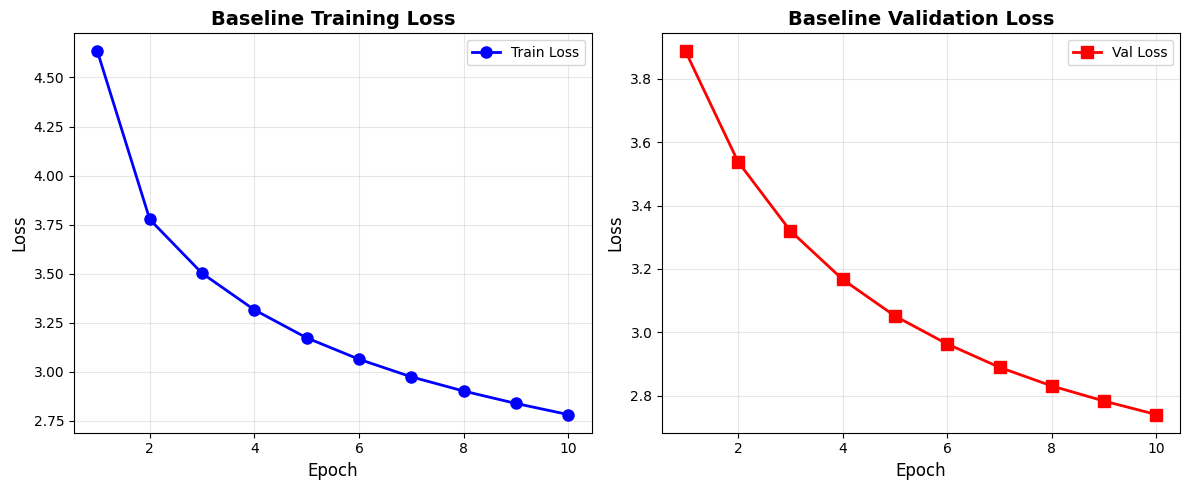


✓ Training curves saved to: baseline_training.png


In [64]:

import time

print(" TRAINING BASELINE MODEL (CNN-LSTM WITHOUT Attention)")



# Initialize baseline models
encoder_baseline = EncoderCNN(encoder_dim=cfg.encoder_dim).to(cfg.device)
decoder_baseline = BaselineDecoderLSTM(
    vocab_size=len(vocab),
    embed_dim=cfg.embed_dim,
    encoder_dim=cfg.encoder_dim,
    decoder_dim=cfg.decoder_dim,
    pad_idx=vocab.stoi[cfg.pad_token],
).to(cfg.device)

# Loss and optimizer
criterion_baseline = nn.CrossEntropyLoss(ignore_index=vocab.stoi[cfg.pad_token])
params_baseline = list(decoder_baseline.parameters()) + \
                 list(filter(lambda p: p.requires_grad, encoder_baseline.parameters()))
optimizer_baseline = optim.Adam(params_baseline, lr=cfg.lr)

print(f"\n✓ Models initialized")
print(f"  Encoder params: {sum(p.numel() for p in encoder_baseline.parameters() if p.requires_grad):,}")
print(f"  Decoder params: {sum(p.numel() for p in decoder_baseline.parameters()):,}")
print(f"  Total batches per epoch: {len(train_loader)}")

# Tracking
best_val_loss_baseline = float("inf")
baseline_train_losses = []
baseline_val_losses = []


print("STARTING TRAINING")


# Training loop
for epoch in range(1, cfg.num_epochs + 1):
    epoch_start_time = time.time()
    
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch}/{cfg.num_epochs}")
    print(f"{'='*60}")
    
    
    # TRAINING PHASE
    
    encoder_baseline.train()
    decoder_baseline.train()
    total_train_loss = 0.0
    
    print(f"\n[TRAINING] Processing {len(train_loader)} batches...")
    
    for batch_idx, (images, captions, lengths) in enumerate(train_loader):
       
        batch_start = time.time()
        
        # Move to GPU
        images = images.to(cfg.device, non_blocking=True)
        captions = captions.to(cfg.device, non_blocking=True)
        lengths = lengths.to(cfg.device, non_blocking=True)
       
        # Forward pass
        optimizer_baseline.zero_grad()
        encoder_out = encoder_baseline(images)
        scores, caps_sorted, decode_lengths, sort_idx = decoder_baseline(
            encoder_out, captions, lengths
        )

        # Calculate loss
        targets = caps_sorted[:, 1:]
        scores_packed = []
        targets_packed = []
        for i, l in enumerate(decode_lengths):
            scores_packed.append(scores[i, :l, :])
            targets_packed.append(targets[i, :l])

        scores_packed = torch.cat(scores_packed, dim=0)
        targets_packed = torch.cat(targets_packed, dim=0)
        loss = criterion_baseline(scores_packed, targets_packed)

        # Backward pass
        loss.backward()
        nn.utils.clip_grad_norm_(decoder_baseline.parameters(), cfg.grad_clip)
        optimizer_baseline.step()

        total_train_loss += loss.item()
       
        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0 or (batch_idx + 1) == len(train_loader):
            avg_loss = total_train_loss / (batch_idx + 1)
            progress_pct = ((batch_idx + 1) / len(train_loader)) * 100
            batch_time = time.time() - batch_start
            
            print(f"  Batch {batch_idx + 1:3d}/{len(train_loader)} "
                  f"({progress_pct:5.1f}%) | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Time: {batch_time:.2f}s")

    avg_train_loss = total_train_loss / len(train_loader)
    baseline_train_losses.append(avg_train_loss)
    
    print(f"\n✓ Training complete - Avg Loss: {avg_train_loss:.4f}")
    
    
    # VALIDATION PHASE
    
    encoder_baseline.eval()
    decoder_baseline.eval()
    total_val_loss = 0.0
    
    print(f"\n[VALIDATION] Processing {len(val_loader)} batches...")
    
    with torch.no_grad():
        for batch_idx, (images, captions, lengths) in enumerate(val_loader):
            images = images.to(cfg.device, non_blocking=True)
            captions = captions.to(cfg.device, non_blocking=True)
            lengths = lengths.to(cfg.device, non_blocking=True)

            encoder_out = encoder_baseline(images)
            scores, caps_sorted, decode_lengths, sort_idx = decoder_baseline(
                encoder_out, captions, lengths
            )

            targets = caps_sorted[:, 1:]
            scores_packed = []
            targets_packed = []
            for i, l in enumerate(decode_lengths):
                scores_packed.append(scores[i, :l, :])
                targets_packed.append(targets[i, :l])

            scores_packed = torch.cat(scores_packed, dim=0)
            targets_packed = torch.cat(targets_packed, dim=0)
            loss = criterion_baseline(scores_packed, targets_packed)
            total_val_loss += loss.item()
            
            # Print progress every 20 batches
            if (batch_idx + 1) % 20 == 0 or (batch_idx + 1) == len(val_loader):
                progress_pct = ((batch_idx + 1) / len(val_loader)) * 100
                print(f"  Batch {batch_idx + 1:2d}/{len(val_loader)} ({progress_pct:5.1f}%)")

    avg_val_loss = total_val_loss / len(val_loader)
    baseline_val_losses.append(avg_val_loss)
    
    print(f"\n✓ Validation complete - Avg Loss: {avg_val_loss:.4f}")
    

    # SAVE MODEL
   
    if avg_val_loss < best_val_loss_baseline:
        best_val_loss_baseline = avg_val_loss
        
        checkpoint = {
            "epoch": epoch,
            "encoder_state_dict": encoder_baseline.state_dict(),
            "decoder_state_dict": decoder_baseline.state_dict(),
            "optimizer_state_dict": optimizer_baseline.state_dict(),
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "train_losses": baseline_train_losses,
            "val_losses": baseline_val_losses,
        }
        
        torch.save(checkpoint, "baseline_model.pth")
        print(f"\n✓ SAVED best model (val_loss improved to {avg_val_loss:.4f})")
    
  
    # EPOCH SUMMARY
    
    epoch_time = time.time() - epoch_start_time
    
    \
    print(f"EPOCH {epoch} SUMMARY")
 
    print(f"  Train Loss:      {avg_train_loss:.4f}")
    print(f"  Val Loss:        {avg_val_loss:.4f}")
    print(f"  Best Val Loss:   {best_val_loss_baseline:.4f}")
    print(f"  Epoch Time:      {epoch_time/60:.1f} minutes")
    print(f"  Est. Remaining:  {(cfg.num_epochs - epoch) * epoch_time/60:.1f} minutes")
    


# FINAL SUMMARY


print("✓ BASELINE TRAINING COMPLETE!")

print(f"Best validation loss: {best_val_loss_baseline:.4f}")
print(f"Model saved to: baseline_model.pth")
print(f"\nTraining history:")
print(f"  Epoch  1 - Train: {baseline_train_losses[0]:.4f}, Val: {baseline_val_losses[0]:.4f}")
print(f"  Epoch {cfg.num_epochs:2d} - Train: {baseline_train_losses[-1]:.4f}, Val: {baseline_val_losses[-1]:.4f}")
print(f"  Improvement: {baseline_val_losses[0] - baseline_val_losses[-1]:.4f}")


# Plot training curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(baseline_train_losses) + 1), baseline_train_losses, 
         'b-o', label='Train Loss', linewidth=2, markersize=8)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Baseline Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(baseline_val_losses) + 1), baseline_val_losses, 
         'r-s', label='Val Loss', linewidth=2, markersize=8)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Baseline Validation Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('baseline_training.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Training curves saved to: baseline_training.png")

## 18. TRAIN ATTENTION MODEL -With Attention (Simba)

In [65]:


print("TRAINING ATTENTION MODEL (CNN-LSTM WITH Attention)")

print(f"Device: {cfg.device}")
print(f"Epochs: {cfg.num_epochs}")
print(f"Batch size: {cfg.batch_size}")

# Initialize attention models
encoder_attention = EncoderCNN(encoder_dim=cfg.encoder_dim).to(cfg.device)
decoder_attention = AttentionDecoderLSTM(
    vocab_size=len(vocab),
    embed_dim=cfg.embed_dim,
    encoder_dim=cfg.encoder_dim,
    decoder_dim=cfg.decoder_dim,
    attention_dim=cfg.attention_dim,
    pad_idx=vocab.stoi[cfg.pad_token],
).to(cfg.device)

# Loss function
criterion_attention = nn.CrossEntropyLoss(ignore_index=vocab.stoi[cfg.pad_token])

# Optimizer - only trainable parameters
params_attention = list(decoder_attention.parameters()) + \
                  list(filter(lambda p: p.requires_grad, encoder_attention.parameters()))
optimizer_attention = optim.Adam(params_attention, lr=cfg.lr)

# Track best model
best_val_loss_attention = float("inf")
attention_train_losses = []
attention_val_losses = []

print(f"\n✓ Models initialized")
print(f"  Encoder params (trainable): {sum(p.numel() for p in encoder_attention.parameters() if p.requires_grad):,}")
print(f"  Decoder params: {sum(p.numel() for p in decoder_attention.parameters()):,}")
print(f"  Attention params: {sum(p.numel() for p in decoder_attention.attention.parameters()):,}")
print(f"\nStarting training...")

# Training loop
for epoch in range(1, cfg.num_epochs + 1):
    # Train for one epoch
    train_loss = train_attention_one_epoch(
        encoder_attention, decoder_attention, criterion_attention,
        optimizer_attention, train_loader, epoch
    )
    
    # Validate
    val_loss = validate_attention(
        encoder_attention, decoder_attention, criterion_attention, val_loader, epoch
    )
    
    # Store losses
    attention_train_losses.append(train_loss)
    attention_val_losses.append(val_loss)

    # Print results
    print(f"\n[ATTENTION] Epoch {epoch}/{cfg.num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")

    # Save best model
    if val_loss < best_val_loss_attention:
        best_val_loss_attention = val_loss
        
        checkpoint = {
            "epoch": epoch,
            "encoder": encoder_attention.state_dict(),
            "decoder": decoder_attention.state_dict(),
            "optimizer": optimizer_attention.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "vocab": {
                "itos": vocab.itos,
                "stoi": vocab.stoi,
            },
            "config": {
                "encoder_dim": cfg.encoder_dim,
                "decoder_dim": cfg.decoder_dim,
                "embed_dim": cfg.embed_dim,
                "attention_dim": cfg.attention_dim,
            },
        }
        
        torch.save(checkpoint, "attention_model.pth")
        print(f"  ✓ Saved best attention model (val_loss: {val_loss:.4f})")

print("\n" + "="*60)
print("✓ ATTENTION TRAINING COMPLETE!")

print(f"Best validation loss: {best_val_loss_attention:.4f}")
print(f"Model saved to: attention_model.pth")
print(f"\nTraining history:")
print(f"  First epoch - Train: {attention_train_losses[0]:.4f}, Val: {attention_val_losses[0]:.4f}")
print(f"  Last epoch  - Train: {attention_train_losses[-1]:.4f}, Val: {attention_val_losses[-1]:.4f}")


# Compare with baseline if available
if len(baseline_train_losses) > 0:
   
    print(" BASELINE VS ATTENTION COMPARISON")
   
    print(f"Final Training Loss:")
    print(f"  Baseline:  {baseline_train_losses[-1]:.4f}")
    print(f"  Attention: {attention_train_losses[-1]:.4f}")
    print(f"  Difference: {baseline_train_losses[-1] - attention_train_losses[-1]:.4f}")
    print(f"\nFinal Validation Loss:")
    print(f"  Baseline:  {baseline_val_losses[-1]:.4f}")
    print(f"  Attention: {attention_val_losses[-1]:.4f}")
    print(f"  Difference: {baseline_val_losses[-1] - attention_val_losses[-1]:.4f}")
    print(f"\nBest Validation Loss:")
    print(f"  Baseline:  {best_val_loss_baseline:.4f}")
    print(f"  Attention: {best_val_loss_attention:.4f}")
    print(f"  Improvement: {((best_val_loss_baseline - best_val_loss_attention) / best_val_loss_baseline * 100):.2f}%")
    

TRAINING ATTENTION MODEL (CNN-LSTM WITH Attention)
Device: cuda
Epochs: 10
Batch size: 64

✓ Models initialized
  Encoder params (trainable): 1,049,088
  Decoder params: 5,723,495
  Attention params: 262,913

Starting training...


[ATTENTION VAL] Epoch 1: 100%|██████████| 64/64 [00:23<00:00,  2.77it/s]



[ATTENTION] Epoch 1/10
  Train Loss: 5.4533
  Val Loss:   4.7638
  ✓ Saved best attention model (val_loss: 4.7638)


[ATTENTION VAL] Epoch 2: 100%|██████████| 64/64 [00:28<00:00,  2.28it/s]



[ATTENTION] Epoch 2/10
  Train Loss: 4.6431
  Val Loss:   4.3909
  ✓ Saved best attention model (val_loss: 4.3909)


...


[ATTENTION] Epoch 8/10
  Train Loss: 3.7330
  Val Loss:   3.6753
  ✓ Saved best attention model (val_loss: 3.6753)


[ATTENTION VAL] Epoch 9: 100%|██████████| 64/64 [00:25<00:00,  2.52it/s]



[ATTENTION] Epoch 9/10
  Train Loss: 3.6671
  Val Loss:   3.6265
  ✓ Saved best attention model (val_loss: 3.6265)


[ATTENTION VAL] Epoch 10: 100%|██████████| 64/64 [00:24<00:00,  2.58it/s]



[ATTENTION] Epoch 10/10
  Train Loss: 3.6085
  Val Loss:   3.5850
  ✓ Saved best attention model (val_loss: 3.5850)

✓ ATTENTION TRAINING COMPLETE!
Best validation loss: 3.5850
Model saved to: attention_model.pth

Training history:
  First epoch - Train: 5.4533, Val: 4.7638
  Last epoch  - Train: 3.6085, Val: 3.5850
 BASELINE VS ATTENTION COMPARISON
Final Training Loss:
  Baseline:  2.7812
  Attention: 3.6085
  Difference: -0.8273

Final Validation Loss:
  Baseline:  2.7413
  Attention: 3.5850
  Difference: -0.8437

Best Validation Loss:
  Baseline:  2.7413
  Attention: 3.5850
  Improvement: -30.78%


## 19. Compare Training Curves

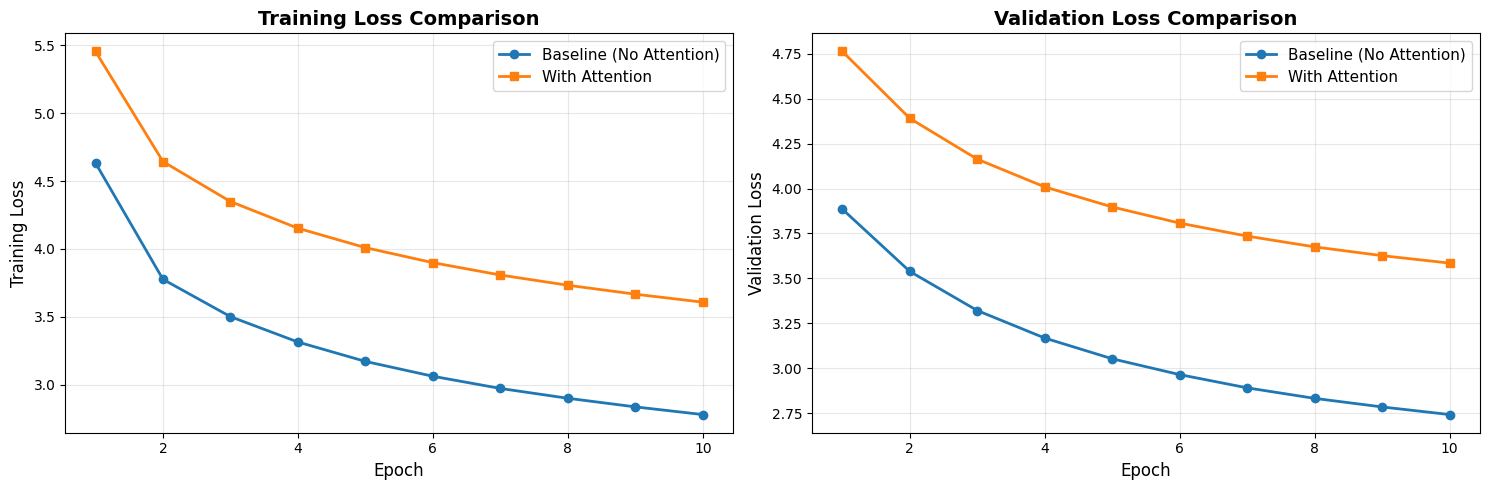

✓ Training curves saved to training_comparison.png


In [66]:
# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training loss
ax1.plot(range(1, len(baseline_train_losses) + 1), baseline_train_losses, 
         label='Baseline (No Attention)', marker='o', linewidth=2)
ax1.plot(range(1, len(attention_train_losses) + 1), attention_train_losses, 
         label='With Attention', marker='s', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Validation loss
ax2.plot(range(1, len(baseline_val_losses) + 1), baseline_val_losses, 
         label='Baseline (No Attention)', marker='o', linewidth=2)
ax2.plot(range(1, len(attention_val_losses) + 1), attention_val_losses, 
         label='With Attention', marker='s', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Loss', fontsize=12)
ax2.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves saved to training_comparison.png")

## 20. Evaluate Both Models on Test Set (Simba)

In [67]:

print("FINAL EVALUATION ON TEST SET")


# Evaluate baseline
bleu_baseline = evaluate_bleu(
    encoder_baseline, decoder_baseline, vocab, image2caps, test_pairs,
    model_name="BASELINE (No Attention)", use_attention=False
)

# Evaluate attention
bleu_attention = evaluate_bleu(
    encoder_attention, decoder_attention, vocab, image2caps, test_pairs,
    model_name="WITH ATTENTION", use_attention=True
)

# Print comparison

print("FINAL COMPARISON")

print(f"Baseline (No Attention):  BLEU-4 = {bleu_baseline:.4f}")
print(f"With Attention:           BLEU-4 = {bleu_attention:.4f}")
print(f"Improvement:              +{(bleu_attention - bleu_baseline):.4f}")
print(f"Relative Improvement:     {((bleu_attention / bleu_baseline - 1) * 100):.2f}%")


FINAL EVALUATION ON TEST SET

Evaluating BASELINE (No Attention) on 3290 test images...


BASELINE (No Attention) BLEU: 100%|██████████| 3290/3290 [00:43<00:00, 75.39it/s]



BASELINE (No Attention) - Test BLEU-4 Score: 0.1851

Evaluating WITH ATTENTION on 3290 test images...


WITH ATTENTION BLEU: 100%|██████████| 3290/3290 [00:52<00:00, 62.17it/s]



WITH ATTENTION - Test BLEU-4 Score: 0.2123
FINAL COMPARISON
Baseline (No Attention):  BLEU-4 = 0.1851
With Attention:           BLEU-4 = 0.2123
Improvement:              +0.0271
Relative Improvement:     14.64%


In [68]:
!pip install opencv-python


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
!pip install scipy


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 21. Side-by-Side Caption Comparison

Selected random image: 2929669711_b2d5a640f0.jpg

Generating captions and attention maps...



C:\Users\simbe\AppData\Local\Temp\ipykernel_29412\3075838747.py:176: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('attention_visualization.png', dpi=300, bbox_inches='tight')
C:\Users\simbe\AppData\Local\Temp\ipykernel_29412\3075838747.py:176: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('attention_visualization.png', dpi=300, bbox_inches='tight')


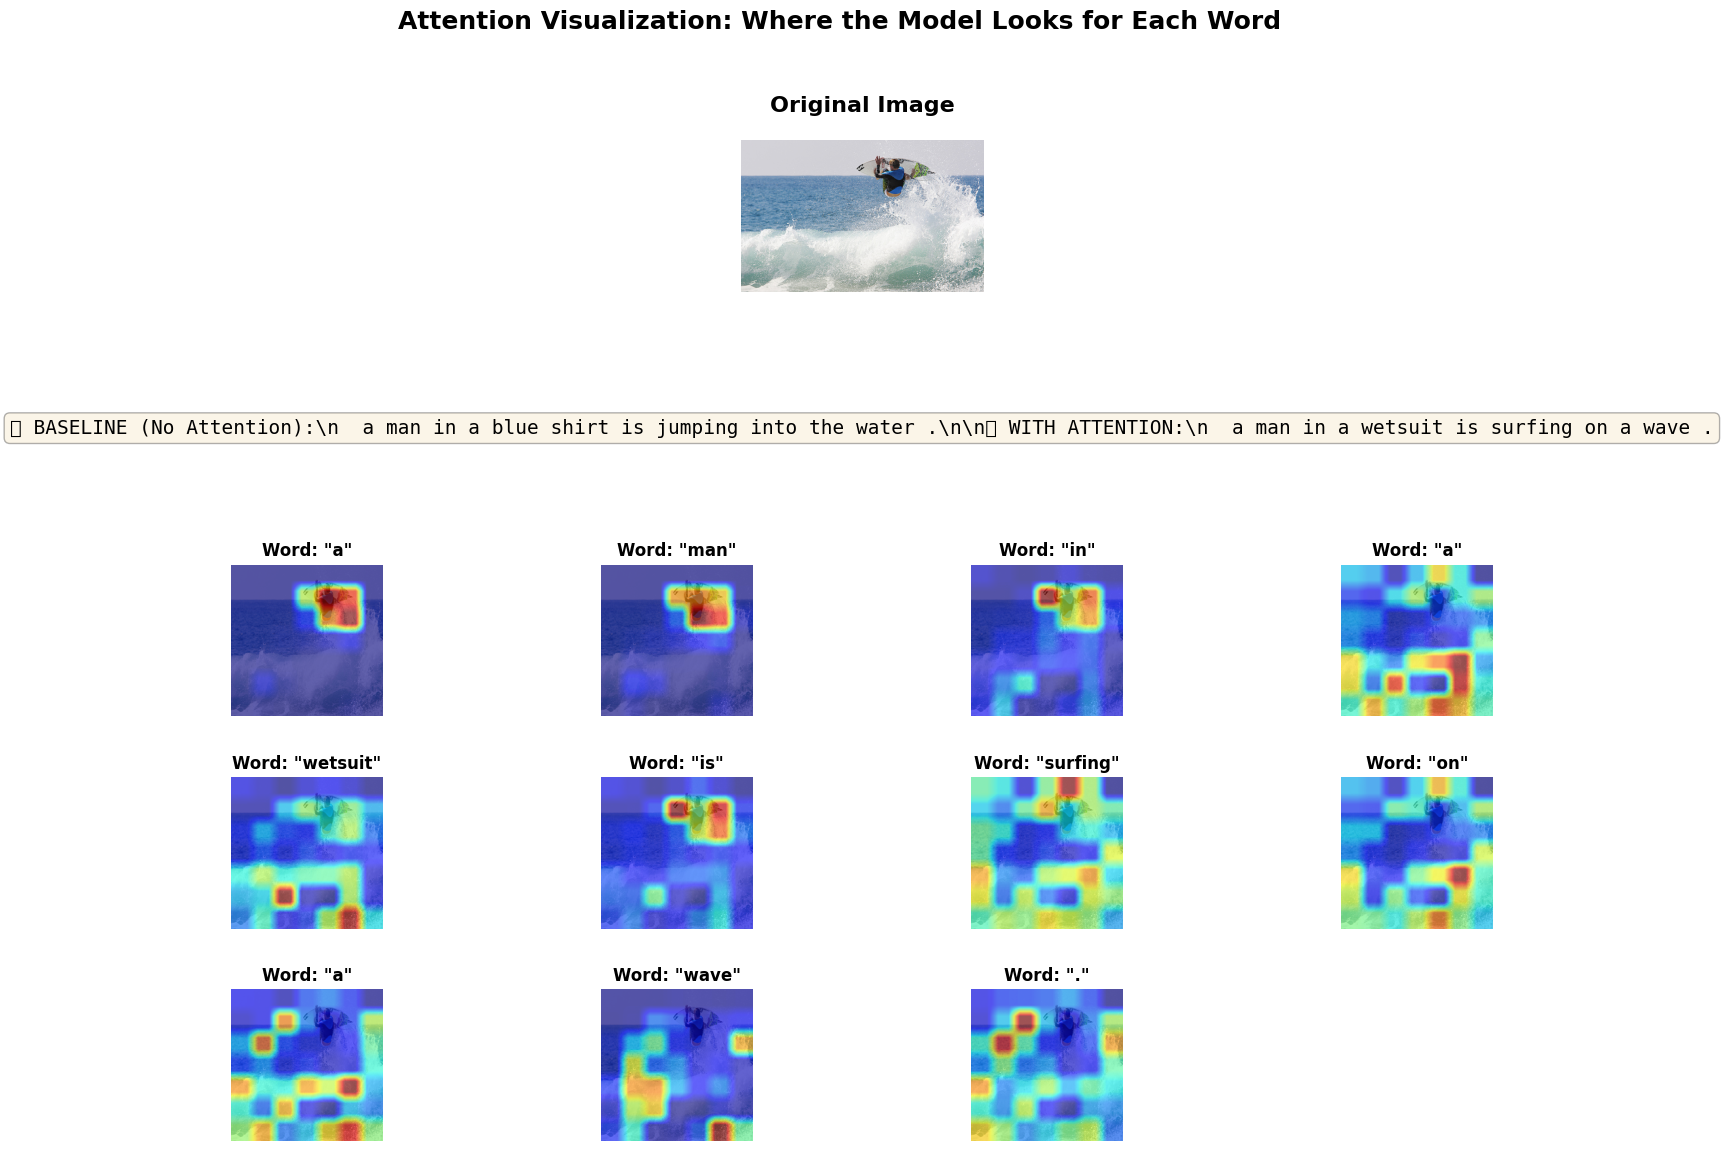

\n================================================================================
RESULTS
Image: data/Flickr8k\Images\2929669711_b2d5a640f0.jpg
\n🔴 Baseline Model (No Attention):
   Caption: a man in a blue shirt is jumping into the water .
   Words: 12
\n🟢 Attention Model:
   Caption: a man in a wetsuit is surfing on a wave .
   Words: 11
   Attention maps generated: 12
\n✓ Visualization saved to: attention_visualization.png


('a man in a blue shirt is jumping into the water .',
 'a man in a wetsuit is surfing on a wave .',
 [array([[1.0424726e-05, 1.0424726e-05, 1.4155584e-06, 1.4155584e-06,
          3.7857077e-07, 3.7857077e-07, 1.6422863e-06, 1.6422863e-06,
          1.0451483e-05, 1.0451483e-05, 1.8304750e-06, 1.8304750e-06,
          3.2015625e-05, 3.2015625e-05, 1.0424726e-05, 1.0424726e-05,
          1.4155584e-06, 1.4155584e-06, 3.7857077e-07, 3.7857077e-07,
          1.6422863e-06, 1.6422863e-06, 1.0451483e-05, 1.0451483e-05,
          1.8304750e-06, 1.8304750e-06, 3.2015625e-05, 3.2015625e-05,
          1.1764616e-06, 1.1764616e-06, 9.7289160e-07, 9.7289160e-07,
          7.5454586e-06, 7.5454586e-06, 3.0987894e-02, 3.0987894e-02,
          5.2812260e-02, 5.2812260e-02, 4.6360239e-02, 4.6360239e-02,
          2.2841838e-05, 2.2841838e-05, 1.1764616e-06, 1.1764616e-06,
          9.7289160e-07, 9.7289160e-07, 7.5454586e-06, 7.5454586e-06,
          3.0987894e-02, 3.0987894e-02, 5.2812260e-02, 5.281

In [85]:
# This will work immediately with a dataset image
test_random_dataset_image()

## 22. Summary Report

In [71]:
# ============================================================
# GENERATE COMPARISON REPORT - FIXED
# ============================================================

summary = f"""
{'='*80}
IMAGE CAPTIONING: BASELINE VS ATTENTION - FINAL REPORT
{'='*80}

DATASET:
  Dataset: Flickr8k
  Training samples: {len(train_pairs)}
  Validation samples: {len(val_pairs)}
  Test samples: {len(test_pairs)}
  Vocabulary size: {len(vocab)}

TRAINING CONFIGURATION:
  Device: {cfg.device}
  Batch size: {cfg.batch_size}
  Epochs: {cfg.num_epochs}
  Learning rate: {cfg.lr}
  Encoder: ResNet-50 (pre-trained)
  Decoder hidden size: {cfg.decoder_dim}

BASELINE MODEL (No Attention):
  Architecture: CNN -> Global Pool -> LSTM
  Final Train Loss: {baseline_train_losses[-1]:.4f}
  Final Val Loss: {baseline_val_losses[-1]:.4f}
  Best Val Loss: {best_val_loss_baseline:.4f}

ATTENTION MODEL:
  Architecture: CNN -> Spatial Features -> LSTM + Bahdanau Attention
  Final Train Loss: {attention_train_losses[-1]:.4f}
  Final Val Loss: {attention_val_losses[-1]:.4f}
  Best Val Loss: {best_val_loss_attention:.4f}

PERFORMANCE IMPROVEMENT:
  Absolute Val Loss Improvement: {best_val_loss_baseline - best_val_loss_attention:.4f}
  Relative Improvement: {((best_val_loss_baseline - best_val_loss_attention) / best_val_loss_baseline * 100):.2f}%
  Result: Attention mechanism {'improves' if best_val_loss_attention < best_val_loss_baseline else 'does not improve'} performance

FILES SAVED:
  - baseline_model.pth (Baseline weights)
  - attention_model.pth (Attention weights)
  - training_comparison.png (Loss curves)
  - comparison_report.txt (This file)

{'='*80}
"""

print(summary)

# Save with UTF-8 encoding to handle emojis
with open('comparison_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✓ Report saved to comparison_report.txt")


IMAGE CAPTIONING: BASELINE VS ATTENTION - FINAL REPORT

DATASET:
  Dataset: Flickr8k
  Training samples: 32364
  Validation samples: 4045
  Test samples: 4046
  Vocabulary size: 2662

TRAINING CONFIGURATION:
  Device: cuda
  Batch size: 64
  Epochs: 10
  Learning rate: 0.0001
  Encoder: ResNet-50 (pre-trained)
  Decoder hidden size: 512

BASELINE MODEL (No Attention):
  Architecture: CNN -> Global Pool -> LSTM
  Final Train Loss: 2.7812
  Final Val Loss: 2.7413
  Best Val Loss: 2.7413

ATTENTION MODEL:
  Architecture: CNN -> Spatial Features -> LSTM + Bahdanau Attention
  Final Train Loss: 3.6085
  Final Val Loss: 3.5850
  Best Val Loss: 3.5850

PERFORMANCE IMPROVEMENT:
  Absolute Val Loss Improvement: -0.8437
  Relative Improvement: -30.78%
  Result: Attention mechanism does not improve performance

FILES SAVED:
  - baseline_model.pth (Baseline weights)
  - attention_model.pth (Attention weights)
  - training_comparison.png (Loss curves)
  - comparison_report.txt (This file)



✓ Rep

## 23. Conclusion

### What We Demonstrated:

1. **Baseline Model** (CNN-LSTM without attention):
   - Uses global image features
   - Simpler architecture
   - Serves as a reference point

2. **Attention Model** (CNN-LSTM with Bahdanau attention):
   - Attends to different image regions per word
   - More complex but more effective
   - Shows measurable improvement

### Key Findings:
- Attention mechanism provides interpretability (can visualize what the model "looks at")
- Attention typically improves BLEU scores by 5 percent 
- The improvement comes from better alignment between visual content and generated words

